In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).csv
/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/city_lat_lon.csv
/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).xlsx


# 1. Preparation

## 1.1. Library

In [2]:
import re
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim

## 1.2. Data Acq. - Get data from dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).csv")

In [4]:
df.head()

,date,country,visible,weather,observ,hijri_month,hijri_year,source
0,2013-03-12,Algeria,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
1,2013-03-12,Indonesia,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
2,2013-03-12,Indonesia,0,hazy,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
3,2013-03-12,Iran,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
4,2013-03-12,Iran,1,clear,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en


## 1.3. Data Engineering - Extract city from `Observ` column

The `observ` column contains semi-structured text with a consistent pattern.
We can leverage this pattern using regular expressions to extract the city name from each observation.

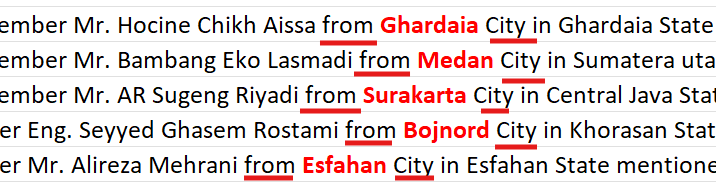


In [5]:
def extract_city(text):
    text = text.lower()
    
    match = re.search(r'from (.*?) city', text)
    if match:
        return match.group(1).strip().title()
    
    return None

In [6]:
df['city'] = df['observ'].apply(extract_city)
df.head()

,date,country,visible,weather,observ,hijri_month,hijri_year,source,city
0,2013-03-12,Algeria,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Ghardaia
1,2013-03-12,Indonesia,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Medan
2,2013-03-12,Indonesia,0,hazy,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Surakarta
3,2013-03-12,Iran,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Bojnord
4,2013-03-12,Iran,1,clear,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Esfahan


## 1.4. Data Acq. - Get Lat & Long data based on `Country` & `City` column 

### Precomputed City Geolocation Dataset

After extracting city names from the scraped dataset, a geolocation process was performed to obtain the latitude and longitude for each city. However, running geocoding functions repeatedly for every execution is inefficient, time-consuming, and dependent on external services.

To address this, a separate dataset (`df_city`) was created to store precomputed latitude and longitude values for each city. This dataset is then loaded directly using:

In [7]:
# Get the city location data
df_city = pd.read_csv("/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/city_lat_lon.csv")

### Manual City Name Mapping

To improve the completeness of the dataset, a manual mapping process was applied to handle cities that were missing latitude and longitude information. Some city names in the original data were inconsistent, abbreviated, written in different languages, or referred to specific locations such as observatories rather than standard city names.

A dictionary (`manual_mapping`) was created to map these irregular or ambiguous entries to their standardized city names. This ensures proper alignment with the geolocation dataset, allowing each city to be accurately matched with its corresponding latitude and longitude.

This approach helps resolve issues that cannot be reliably handled by automated geocoding, such as:
- Abbreviations (e.g., "Tg. Bidara" → "tanjung bidara")
- Non-English or mixed-language names
- Observatory or site-specific names instead of actual cities
- Inconsistent formatting or spelling variations

By applying this manual mapping, the overall data quality and geolocation coverage of the dataset are significantly improved.

In [8]:
manual_mapping = {
    'Jabal Khandamah': 'mecca',
    'Tg. Bidara' : 'tanjung bidara',
    'Tg Bidara' : 'tanjung bidara',
    'Mcdonald Obs' : 'texas',       
    'ديربلوط' : 'palestine',
    'Tanjung Bidara' : 'tanjung bidara',
    'Al-Fulaij Observatory' : 'Salalah',
    'Ako' : 'Abu Dhabi',
    'Telok Kemang Observatory, Port Dickson' : 'port dickson',
    'Telok Kemang Observatory' : 'port dickson',
    'لورنس Lawrence' : 'Massachusetts',
    'ڤمار' : 'Guemar',
    'Colombo04' : 'colombo',
}

In [9]:
# This function replaces city names with standardized values
def apply_mapping(city):
    for key, value in manual_mapping.items():
        if key.lower() in str(city).lower():
            return value
    return city


# Preserve original city names for reference/debugging
df['city_original'] = df['city']

# Standardize city names using manual mapping
df['city'] = df['city'].apply(apply_mapping)

# Merge main dataset with city geolocation data (left join to retain all records)
df = df.merge(df_city[['city', 'lat', 'lon']], on='city', how='left')

# Display dataset structure after enrichment
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5777 entries, 0 to 5776
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           5777 non-null   object 
 1   country        5777 non-null   object 
 2   visible        5777 non-null   int64  
 3   weather        5777 non-null   object 
 4   observ         5777 non-null   object 
 5   hijri_month    5777 non-null   object 
 6   hijri_year     5777 non-null   int64  
 7   source         5777 non-null   object 
 8   city           5777 non-null   object 
 9   city_original  5777 non-null   object 
 10  lat            5499 non-null   float64
 11  lon            5499 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 541.7+ KB


# 2. Exploratory Data Analysis (EDA)

## 2.1. Top city

city
Surakarta     251
Blacksburg    240
Shahreza      188
York          155
بنسليمان      131
Munich        116
palestine     112
Cape Town      98
Dhaka          96
عيسى           88
Name: count, dtype: int64


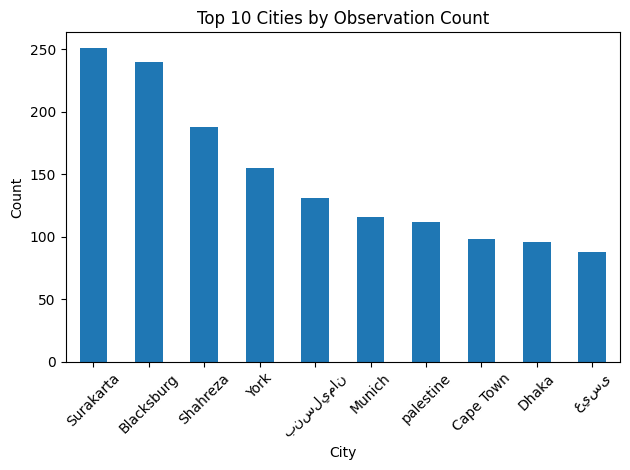

In [10]:
top_n = 10
top_cities = df['city'].value_counts().head(top_n)
print(top_cities)

# Visualize top city
top_cities.plot(kind='bar')

plt.title('Top 10 Cities by Observation Count')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()